# Electric Vehicle Market Analysis



## Project Overview



This project explores the electric vehicle (EV) market through exploratory data analysis (EDA) using Python.

The analysis focuses on identifying market trends, manufacturer participation, geographic distribution, and the evolution of electric vehicle adoption. The objective is to extract actionable insights from publicly available data and demonstrate the complete workflow of a data analysis project, including data cleaning, visualization, and interpretation.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [ ]:
# Configure visualization settings
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.3
})

## Data Acquisition

The dataset is loaded directly from a public Google Sheets document to ensure that the analysis is fully reproducible.

In [ ]:
# Load the electric vehicle dataset
sheet_id = "1EvSrAe5JUoDUjU4x8Mm43q41Zecnov0wL4h8BbOT18M"
gid = "86233506"

csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

ev_df = pd.read_csv(csv_url)

## Project Scope

This project aims to analyze the electric vehicle market using exploratory data analysis (EDA). The analysis focuses on identifying market trends, understanding the distribution of electric vehicles, and uncovering patterns that can support data-driven decision-making.

## Initial Data Exploration

In [ ]:
# Initial data exploration

ev_df.head()

ev_df.info()

print(f"Dataset dimensions: {ev_df.shape[0]} rows × {ev_df.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

## Geographic Coverage
The dataset contains electric vehicle registration records from multiple U.S. states. Before focusing the analysis, it is useful to examine the geographic coverage of the dataset and identify the states with the largest number of records.

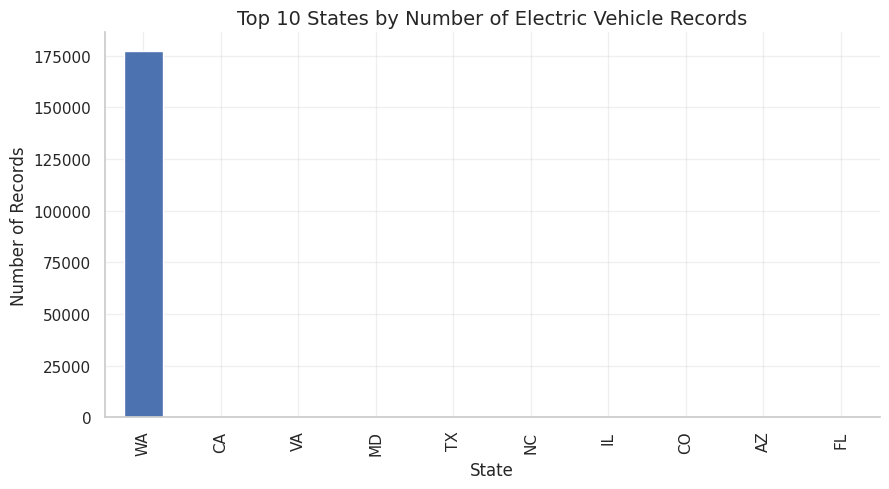

In [ ]:
state_counts = ev_df["State"].value_counts()

state_counts.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 States by Number of Electric Vehicle Records")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.show()

In [ ]:
state_distribution = ev_df["State"].value_counts(normalize=True) * 100

washington_pct = state_distribution["WA"]

print(f"Washington represents {washington_pct:.2f}% of all records.")

Washington represents 99.78% of all records.


### Scope Refinement

An initial exploration of the dataset shows that more than 99% of the records correspond to the state of Washington.

To ensure that the analysis accurately reflects the available data and avoids unsupported generalizations, the remainder of this project focuses exclusively on electric vehicle registrations in Washington State.

This decision improves the reliability of the findings by limiting the analysis to the region that is adequately represented in the dataset.

## Data Cleaning
The goal of this stage is to improve the quality of the dataset by identifying missing values, duplicate records, and potential data quality issues. This process ensures that the dataset is reliable and ready for the subsequent analysis.



In [ ]:
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

In [ ]:
print(f"Dataset dimensions: {ev_df.shape[0]:,} rows × {ev_df.shape[1]} columns")

Dataset dimensions: 177,866 rows × 17 columns


In [ ]:
# Inspect the distribution of model years
ev_df["Model Year"].value_counts().sort_index()

,count
Model Year,
1997,1
1998,1
1999,5
2000,7
2002,2
2003,1
2008,20
2010,23
2011,775


In [ ]:
#Check for duplicate records
ev_df.duplicated().sum()

In [ ]:
# Verify that each vehicle has a unique identifier
ev_df["DOL Vehicle ID"].duplicated().sum()

np.int64(0)

In [ ]:
# Review the distribution of electric range values
ev_df["Electric Range"].describe()

,Electric Range
count,177866.000000
mean,58.842162
std,91.981298
min,0.000000
25%,0.000000
50%,0.000000
75%,75.000000
max,337.000000


In [ ]:
# Check for vehicles with a recorded electric range of zero
(ev_df["Electric Range"] == 0).sum()

np.int64(91950)

In [ ]:
# Since many records have an electric range of zero, check whether this is associated with the vehicle type.
ev_df.groupby("Electric Vehicle Type")["Electric Range"].describe()

,count,mean,std,min,25%,50%,75%,max
Electric Vehicle Type,,,,,,,,
Battery Electric Vehicle (BEV),139210.0,66.627318,102.288591,0.0,0.0,0.0,150.0,337.0
Plug-in Hybrid Electric Vehicle (PHEV),38656.0,30.805852,15.658229,6.0,21.0,28.0,38.0,153.0


The results indicate that most records with an electric range of zero correspond to Battery Electric Vehicles (BEVs). Since BEVs are expected to have a measurable electric driving range, these zero values may represent missing or inaccurately reported data. Therefore, these records will be handled carefully during the electric range analysis.

In [ ]:
# Review the distribution of base MSRP values
ev_df["Base MSRP"].describe()

,Base MSRP
count,177866.000000
mean,1073.109363
std,8358.624956
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,845000.000000


In [ ]:
# Count records with a base MSRP of zero
(ev_df["Base MSRP"] == 0).sum()

np.int64(174522)

The summary statistics indicate that at least 75% of the records have a base MSRP of zero. A further inspection shows that approximately 98% of all records contain a value of zero. Because of the large proportion of missing or non-informative values, this variable provides limited analytical value and will be excluded from the remainder of the analysis.

In [ ]:
# Count the number of unique vehicle manufacturers
ev_df["Make"].nunique()

40

In [ ]:
# Review the list of vehicle manufacturers for consistency
sorted(ev_df["Make"].unique())

['ALFA ROMEO',
 'AUDI',
 'AZURE DYNAMICS',
 'BENTLEY',
 'BMW',
 'CADILLAC',
 'CHEVROLET',
 'CHRYSLER',
 'DODGE',
 'FIAT',
 'FISKER',
 'FORD',
 'GENESIS',
 'GMC',
 'HONDA',
 'HYUNDAI',
 'JAGUAR',
 'JEEP',
 'KIA',
 'LAND ROVER',
 'LEXUS',
 'LINCOLN',
 'LUCID',
 'MAZDA',
 'MERCEDES-BENZ',
 'MINI',
 'MITSUBISHI',
 'NISSAN',
 'POLESTAR',
 'PORSCHE',
 'RIVIAN',
 'ROLLS ROYCE',
 'SMART',
 'SUBARU',
 'TESLA',
 'TH!NK',
 'TOYOTA',
 'VOLKSWAGEN',
 'VOLVO',
 'WHEEGO ELECTRIC CARS']

The Make column appears to be clean and consistent, with no obvious data quality issues.


## Exploratory Data Analysis

This section explores the main characteristics of the electric vehicle market in Washington. The objective is to identify patterns, trends, and relationships between variables that will support the subsequent analysis and modeling.

In [ ]:
# Review the distribution of electric vehicle types
ev_df["Electric Vehicle Type"].value_counts()

,count
Electric Vehicle Type,
Battery Electric Vehicle (BEV),139210
Plug-in Hybrid Electric Vehicle (PHEV),38656


Most electric vehicles registered in Washington are Battery Electric Vehicles (BEVs), while Plug-in Hybrid Electric Vehicles (PHEVs) account for approximately one-fifth of the market (38,656 out of 177,866 vehicles, or about 21.7%).

In [ ]:
# Display the 20 counties with the highest number of registered electric vehicles
ev_df["County"].value_counts().head(20)

,count
County,
King,92740
Snohomish,21001
Pierce,13782
Clark,10416
Thurston,6428
Kitsap,5840
Spokane,4586
Whatcom,4253
Benton,2147


### Market Evolution
How has the market evolved over time?

In [ ]:
vehicles_by_model_year = (
    ev_df[ev_df["State"] == "WA"]["Model Year"]
    .value_counts()
    .sort_index()
)

vehicles_by_model_year

,count
Model Year,
1997,1
1998,1
1999,5
2000,7
2002,2
2003,1
2008,19
2010,23
2011,775


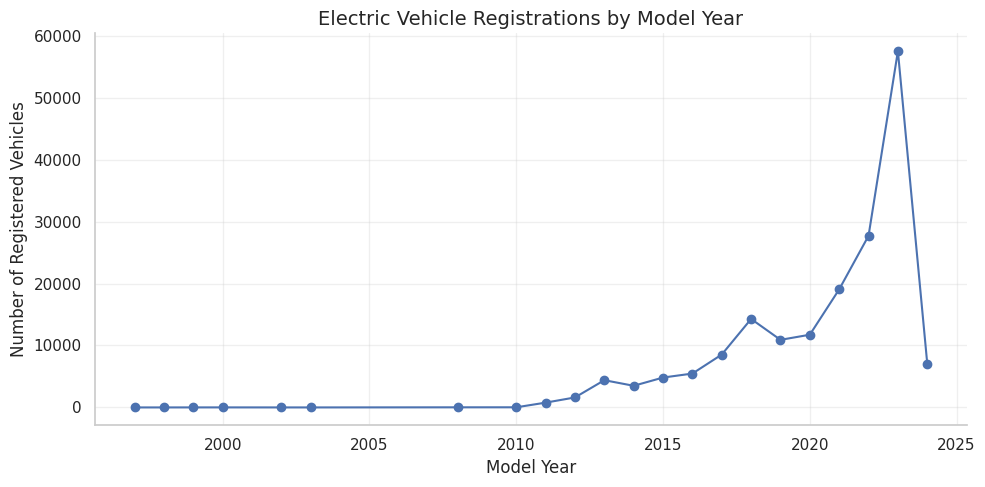

In [ ]:
vehicles_by_model_year.plot(
    kind="line",
    marker="o"
)

plt.title("Electric Vehicle Registrations by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Registered Vehicles")

plt.tight_layout()
plt.show()

Electric vehicle registrations increase steadily over time, with particularly rapid growth after 2020. This trend suggests an accelerated adoption of electric vehicles in Washington during recent model years.

### Vehicle Manufacturers
Which manufacturers dominate the market?

In [ ]:
top_manufacturers = ev_df["Make"].value_counts().head(15)

top_manufacturers

,count
Make,
TESLA,79659
NISSAN,13998
CHEVROLET,13678
FORD,9199
BMW,7570
KIA,7432
TOYOTA,6288
VOLKSWAGEN,5004
JEEP,4480


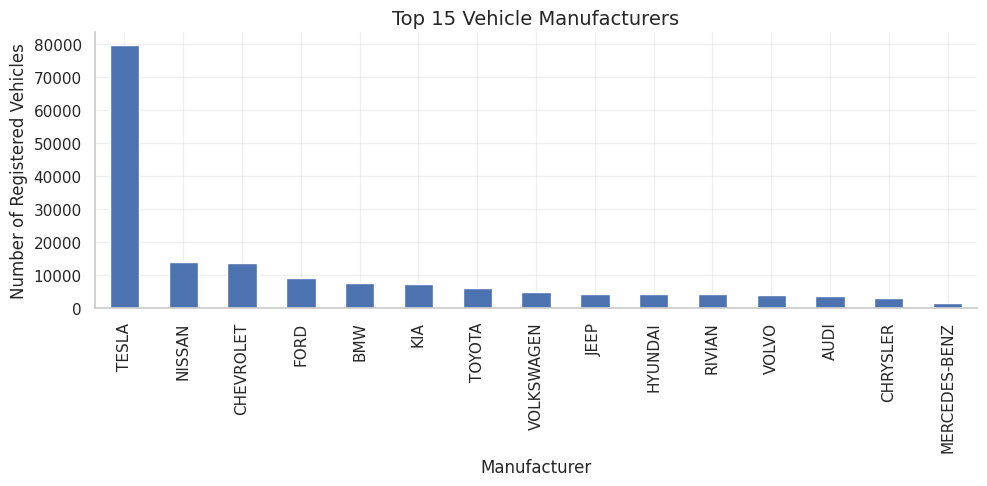

In [ ]:
top_manufacturers.plot(kind="bar")

plt.title("Top 15 Vehicle Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Registered Vehicles")

plt.tight_layout()
plt.show()

Tesla dominates the Washington EV market by a wide margin, followed by Nissan and several traditional automakers. This indicates a highly concentrated market led by one manufacturer.

### Vehicle Models
Which vehicle models are the most common?

In [ ]:
top_models = ev_df["Model"].value_counts().head(20)

top_models

,count
Model,
MODEL Y,35989
MODEL 3,30092
LEAF,13366
MODEL S,7735
BOLT EV,6821
MODEL X,5796
VOLT,4796
ID.4,3937
WRANGLER,3392


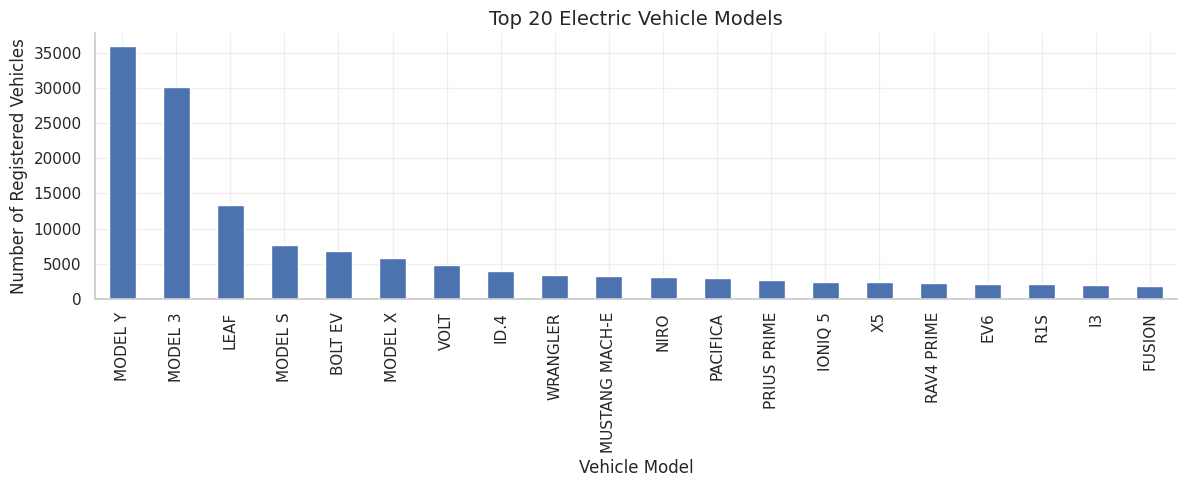

In [ ]:
top_models.plot(kind="bar", figsize=(12, 5))

plt.title("Top 20 Electric Vehicle Models")
plt.xlabel("Vehicle Model")
plt.ylabel("Number of Registered Vehicles")

plt.tight_layout()
plt.show()

Tesla Model Y and Model 3 are the most frequently registered vehicles, reflecting Tesla's dominant position in the state's electric vehicle market.

### Electric Vehicle Types
What is the composition of the electric vehicle market in Washington?\
And how does electric range vary between different types of electric vehicles?

In [ ]:
ev_type_distribution = ev_df["Electric Vehicle Type"].value_counts()

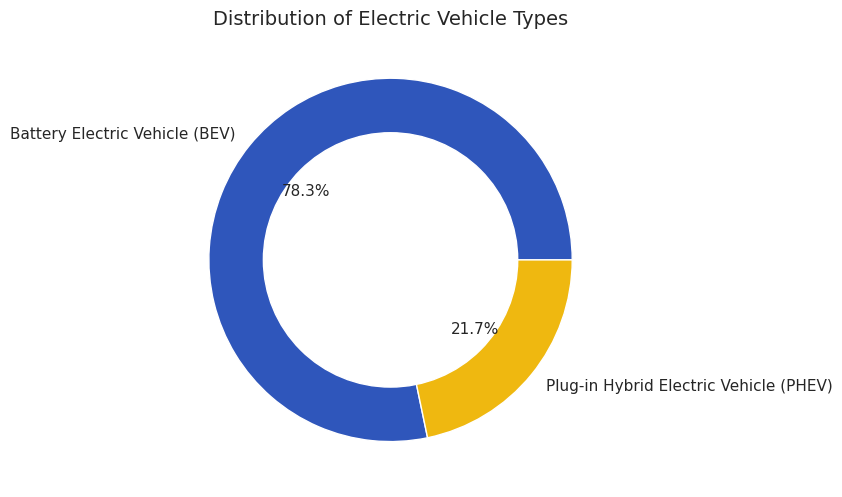

In [ ]:
colors = ["#2F56BB", "#EFB810"]

plt.figure(figsize=(8, 8))

plt.pie(
   ev_type_distribution,
    labels = ev_type_distribution.index,
    autopct = "%1.1f%%",
    colors = colors
)

# Add a white circle to create a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Distribution of Electric Vehicle Types")

plt.tight_layout()
plt.show()

Battery Electric Vehicles (BEVs) represent the majority of registered electric vehicles in the dataset, indicating a stronger adoption compared with Plug-in Hybrid Electric Vehicles (PHEVs).

In [ ]:
ev_df.groupby("Electric Vehicle Type")["Electric Range"].describe()

,count,mean,std,min,25%,50%,75%,max
Electric Vehicle Type,,,,,,,,
Battery Electric Vehicle (BEV),139210.0,66.627318,102.288591,0.0,0.0,0.0,150.0,337.0
Plug-in Hybrid Electric Vehicle (PHEV),38656.0,30.805852,15.658229,6.0,21.0,28.0,38.0,153.0


BEVs generally show higher electric ranges compared with PHEVs, which is consistent with their fully electric design. PHEVs typically have lower electric ranges because they combine electric and gasoline power systems.

### Geographic Distribution (Counties)
Which counties have the highest number of registered electric vehicles?

In [ ]:
top_counties = ev_df["County"].value_counts().head(10)

top_counties

,count
County,
King,92740
Snohomish,21001
Pierce,13782
Clark,10416
Thurston,6428
Kitsap,5840
Spokane,4586
Whatcom,4253
Benton,2147


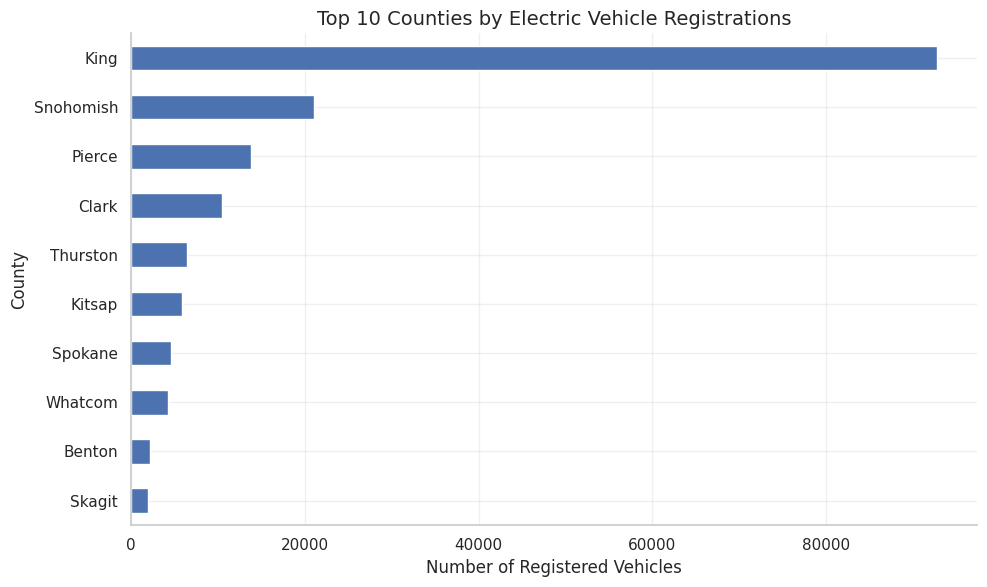

In [ ]:
plt.figure(figsize=(10, 6))

top_counties.sort_values().plot(kind="barh")

plt.title("Top 10 Counties by Electric Vehicle Registrations")
plt.xlabel("Number of Registered Vehicles")
plt.ylabel("County")

plt.tight_layout()
plt.show()

These results indicate that future analyses of the Washington electric vehicle market should consider the geographic concentration of registrations, as statewide trends may be strongly driven by a relatively small number of counties.

### Electric Range Distribution
How is the electric range distributed among the vehicles in the dataset? \
And how does it change when excluding zero values?

In [ ]:
ev_df["Electric Range"].describe()

,Electric Range
count,177866.000000
mean,58.842162
std,91.981298
min,0.000000
25%,0.000000
50%,0.000000
75%,75.000000
max,337.000000


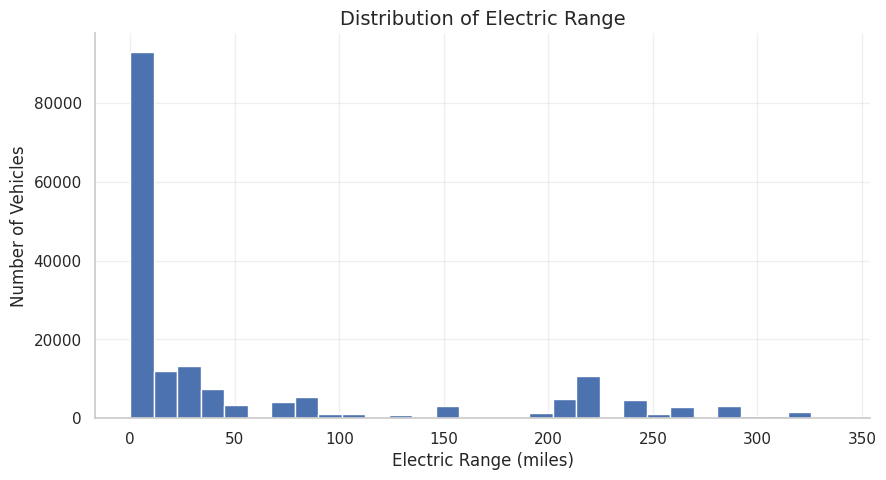

In [ ]:
plt.hist(ev_df["Electric Range"], bins=30)

plt.title("Distribution of Electric Range")
plt.xlabel("Electric Range (miles)")
plt.ylabel("Number of Vehicles")

plt.show()

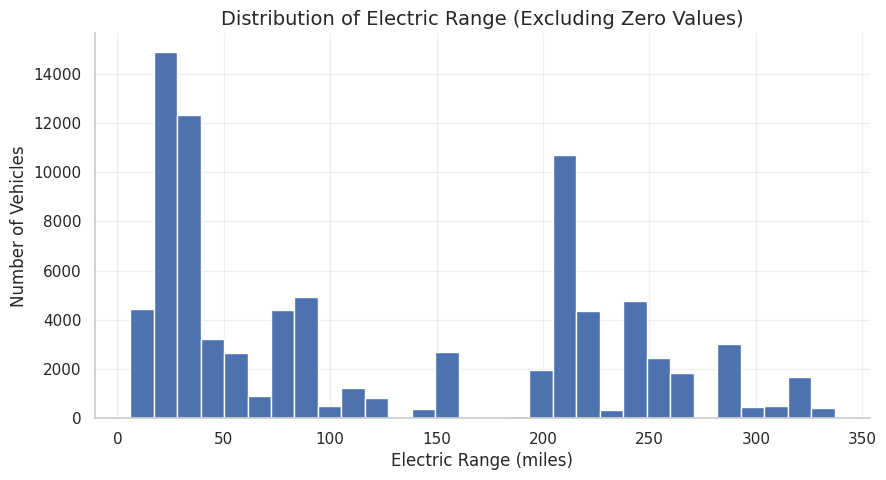

In [ ]:
range_without_zeros = ev_df[ev_df["Electric Range"] > 0]["Electric Range"]

plt.hist(range_without_zeros, bins=30)

plt.title("Distribution of Electric Range (Excluding Zero Values)")
plt.xlabel("Electric Range (miles)")
plt.ylabel("Number of Vehicles")

plt.show()

The original distribution shows a large concentration of vehicles with zero reported range, which affects the overall view of the data. After excluding zero values, the distribution provides a clearer representation of actual reported electric ranges, with most vehicles concentrated in low-to-medium range values.

### CAFV Eligibility Status
What proportion of vehicles meet the Clean Alternative Fuel Vehicle eligibility criteria?

In [ ]:
ev_df["Clean Alternative Fuel Vehicle (CAFV) Eligibility"].value_counts()

,count
Clean Alternative Fuel Vehicle (CAFV) Eligibility,
Eligibility unknown as battery range has not been researched,91950
Clean Alternative Fuel Vehicle Eligible,66331
Not eligible due to low battery range,19585


A large portion of vehicles have an unknown CAFV eligibility status, while eligible vehicles represent a significant share of the dataset. This suggests that eligibility information may have incomplete reporting and should be considered when analyzing policy-related trends.

### Summary
The exploratory analysis highlights the characteristics of the electric vehicle market in Washington, which is dominated by Battery Electric Vehicles (BEVs) and led primarily by Tesla. Electric vehicle registrations are concentrated in a small number of counties, while electric range varies considerably across vehicle types. Electric range also varies across vehicle types, with BEVs generally showing higher reported ranges than PHEVs. Overall, the dataset reflects both the geographic concentration and technological diversity of the state's EV market.

## Analysis of Variable Relationships




### Electric Vehicle Type Across Model Years

**How has the composition of electric vehicle types varied across model years?**

In [ ]:
ev_type_by_year = pd.crosstab(
    ev_df["Model Year"],
    ev_df["Electric Vehicle Type"]
)

ev_type_by_year

Electric Vehicle Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Model Year,,
1997,1,0
1998,1,0
1999,5,0
2000,7,0
2002,2,0
2003,1,0
2008,20,0
2010,20,3
2011,699,76


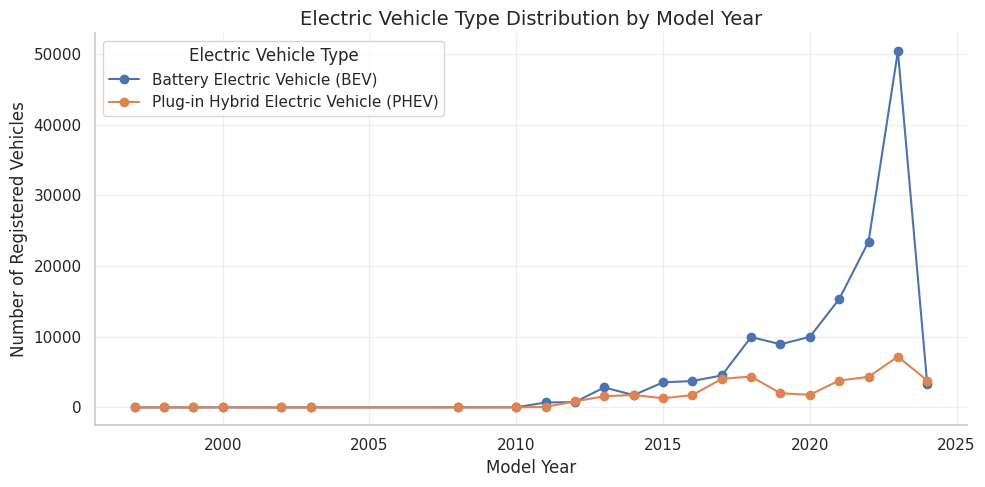

In [ ]:
ev_type_by_year.plot(marker="o")

plt.title("Electric Vehicle Type Distribution by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Registered Vehicles")

plt.tight_layout()
plt.show()

Until 2016, BEVs and PHEVs showed relatively similar numbers of vehicles. Starting in 2017, a clear divergence emerged between the two segments. From 2020 onward, BEV model years became substantially more prevalent than PHEV model years, making BEVs the dominant vehicle type among the more recent model years represented in the dataset.

### Manufacturer Registration Share

**How concentrated are electric vehicle registrations among manufacturers?**

In [ ]:
manufacturer_share = (
    ev_df["Make"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

manufacturer_share.head(15)

,proportion
Make,
TESLA,44.79
NISSAN,7.87
CHEVROLET,7.69
FORD,5.17
BMW,4.26
KIA,4.18
TOYOTA,3.54
VOLKSWAGEN,2.81
JEEP,2.52


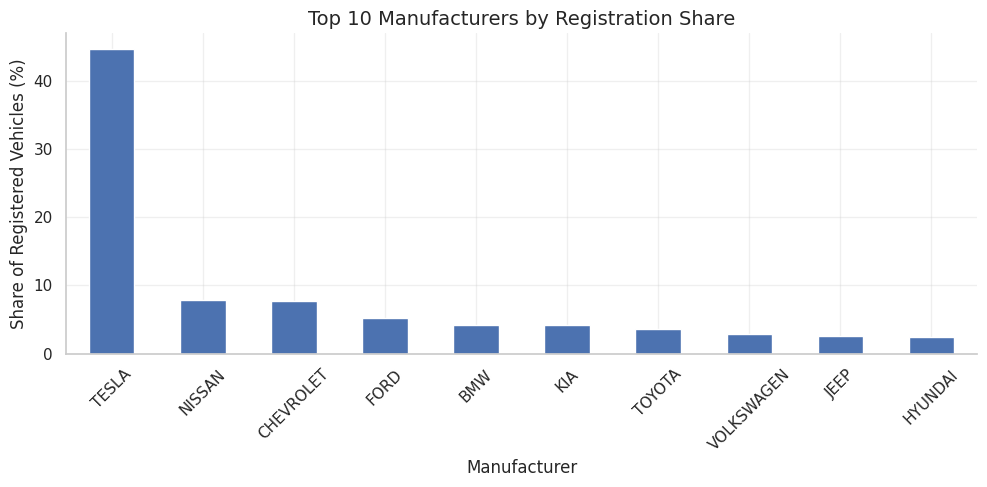

In [ ]:
top10_manufacturer_share = manufacturer_share.head(10)

top10_manufacturer_share.plot(kind="bar")

plt.title("Top 10 Manufacturers by Registration Share")
plt.xlabel("Manufacturer")
plt.ylabel("Share of Registered Vehicles (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Vehicle Type by Manufacturer

How does the distribution of vehicle types vary across the leading manufacturers?

In [ ]:
vehicle_type_by_make = (
    pd.crosstab(
      ev_df["Make"],
      ev_df["Electric Vehicle Type"]
    ).sort_values(
      by="Battery Electric Vehicle (BEV)",
      ascending=False
    ).head(10)
)

vehicle_type_by_make

Electric Vehicle Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Make,,
TESLA,79659,0
NISSAN,13998,0
CHEVROLET,8882,4796
FORD,5517,3682
KIA,5039,2393
VOLKSWAGEN,5004,0
RIVIAN,4312,0
HYUNDAI,3775,631
BMW,2515,5055


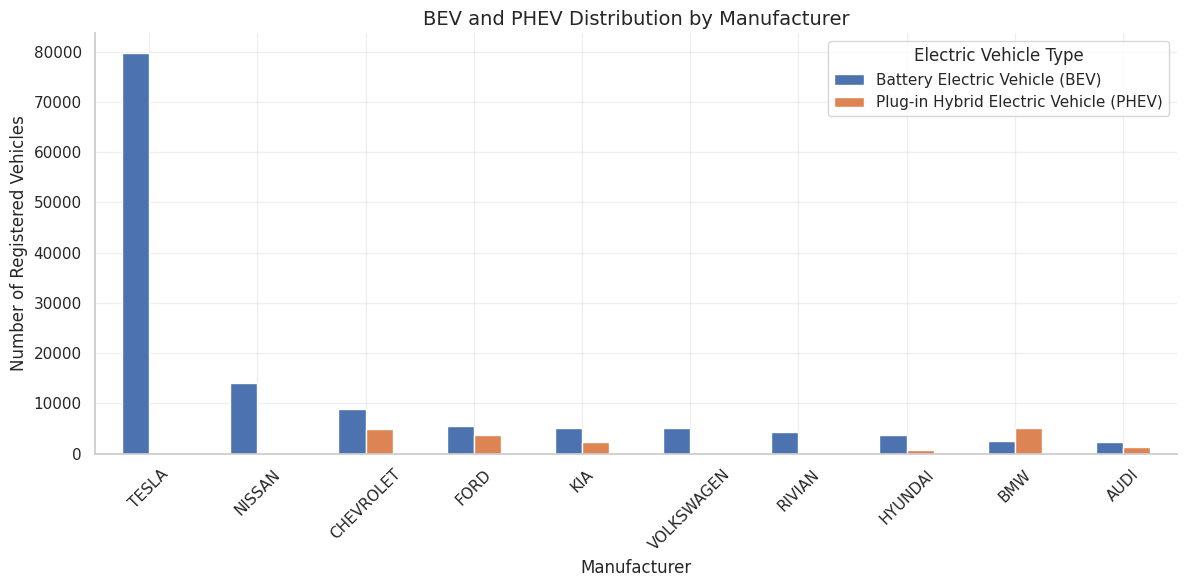

In [ ]:
vehicle_type_by_make.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("BEV and PHEV Distribution by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Registered Vehicles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Tesla clearly dominates the BEV segment, with a substantially larger number of vehicles than any other manufacturer. Nissan ranks a distant second and is also primarily represented by BEVs. From the third position onward, the market becomes more competitive, with several manufacturers showing relatively similar BEV volumes, while many of them offering both BEV and PHEV models.

# Key Findings

### Validation Against Industry Trends

The results obtained from the analysis of the Washington dataset are broadly consistent with trends reported by international organizations specializing in electric mobility. According to the International Energy Agency (IEA), global electric vehicle sales exceeded 20 million units in 2025, accounting for approximately one-quarter of global car sales. The IEA also reports that battery electric vehicles (BEVs) continue to be a major driver of growth in the electric vehicle market.

These broader trends are consistent with several findings from the present analysis. The dataset shows a greater prevalence of BEVs among more recent model years, a strong representation of BEVs overall, and a high concentration of vehicle registrations among a relatively small number of leading manufacturers and models. Therefore, the patterns observed in Washington appear broadly aligned with the broader global transition toward electric mobility.


### Market Outlook and Implications

**How are registered electric vehicles distributed across model years in Washington?**

In [ ]:
# Count registered EVs in Washington by model year
vehicles_by_model_year = (
    ev_df[ev_df["State"] == "WA"]["Model Year"]
    .value_counts()
    .sort_index()
)

vehicles_by_model_year

,count
Model Year,
1997,1
1998,1
1999,5
2000,7
2002,2
2003,1
2008,19
2010,23
2011,775


In [ ]:
# Convert the model-year distribution into a DataFrame for further analysis
model_year_df = vehicles_by_model_year.reset_index()
model_year_df.columns = ["Model Year", "Vehicles"]

model_year_df

,Model Year,Vehicles
0,1997,1
1,1998,1
2,1999,5
3,2000,7
4,2002,2
5,2003,1
6,2008,19
7,2010,23
8,2011,775
9,2012,1614


In [ ]:
# Exclude 2024 because the available records appear incomplete.
# The model will later be used to estimate a more consistent value for this year.
model_df = model_year_df[model_year_df["Model Year"] < 2024]

model_df

,Model Year,Vehicles
0,1997,1
1,1998,1
2,1999,5
3,2000,7
4,2002,2
5,2003,1
6,2008,19
7,2010,23
8,2011,775
9,2012,1614


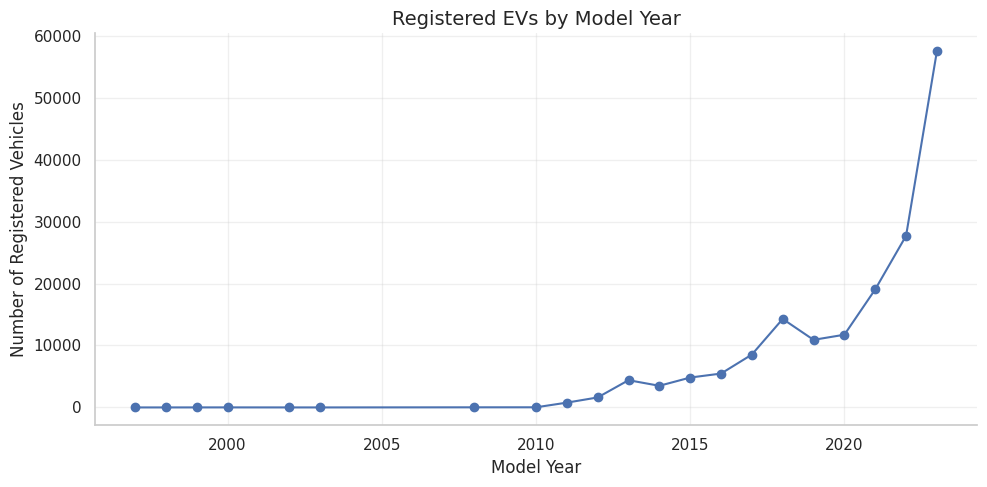

In [ ]:
plt.scatter(
    model_df["Model Year"],
    model_df["Vehicles"]
)

plt.plot(
    model_df["Model Year"],
    model_df["Vehicles"]
)

plt.title("Registered EVs by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Registered Vehicles")

plt.tight_layout()
plt.show()

In [ ]:
# Calculate the percentage change in vehicle counts between consecutive model years
model_df["VehicleCount_Change_%"] = (
   model_df["Vehicles"]
   .pct_change()
   .mul(100)
)

model_df

/tmp/ipykernel_735/2747302421.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df["VehicleCount_Change_%"] = (


,Model Year,Vehicles,VehicleCount_Change_%
0,1997,1,NaN
1,1998,1,0.000000
2,1999,5,400.000000
3,2000,7,40.000000
4,2002,2,-71.428571
5,2003,1,-50.000000
6,2008,19,1800.000000
7,2010,23,21.052632
8,2011,775,3269.565217
9,2012,1614,108.258065


### Linear Regression Model

**Can the number of registered vehicles associated with the 2024 model year be estimated from the trend observed in previous model years?**

In [ ]:
# Select recent model years for the linear regression analysis
recent_model_df = model_df[
    model_df["Model Year"] >= 2015
]

recent_model_df

,Model Year,Vehicles,VehicleCount_Change_%
12,2015,4826,38.043478
13,2016,5469,13.323663
14,2017,8536,56.079722
15,2018,14286,67.361762
16,2019,10913,-23.610528
17,2020,11740,7.578118
18,2021,19063,62.376491
19,2022,27709,45.354876
20,2023,57520,107.585983


In [ ]:
X = recent_model_df[["Model Year"]]
y = recent_model_df["Vehicles"]

In [ ]:
X.head()

,Model Year
12,2015
13,2016
14,2017
15,2018
16,2019


In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X, y)

LinearRegression()

In [ ]:
y_pred = linear_model.predict(X)

In [ ]:
# Evaluate the model using the coefficient of determination (R²)
r_squared = linear_model.score(X, y)
print(f"R²: {r_squared:.3f}")

R²: 0.670


In [ ]:
# Evaluate the model on the training data
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

MAE: 6,958.68
RMSE: 8,943.38


### Visualizing the Linear Regression

The observed values and the fitted linear regression line are plotted to visually assess how well the model represents the relationship between model year and the number of registered vehicles.

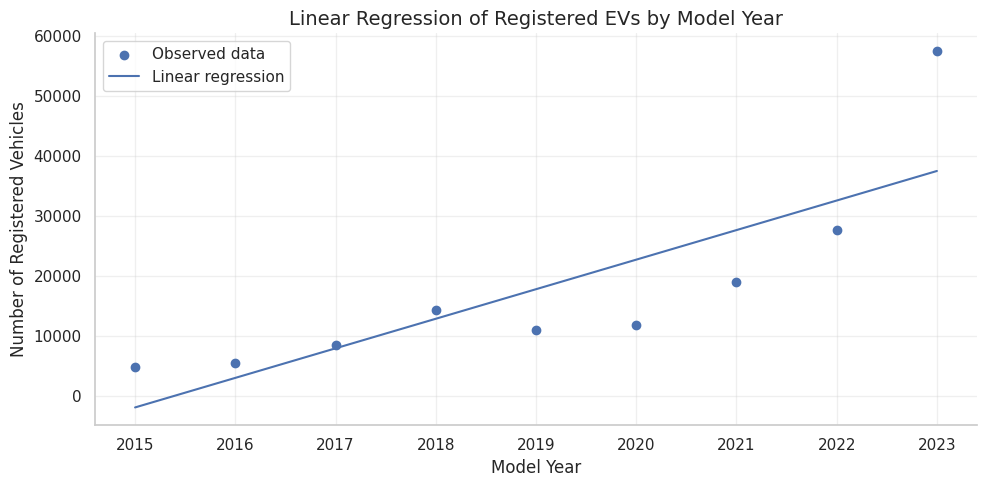

In [ ]:
plt.scatter(
    X,
    y,
    label="Observed data"
)

plt.plot(
    X,
    y_pred,
    label="Linear regression"
)

plt.title("Linear Regression of Registered EVs by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Registered Vehicles")

plt.legend()
plt.tight_layout()
plt.show()

The fitted linear regression is defined by an intercept and a slope. The slope represents the estimated change in the number of registered vehicles associated with a one-year increase in model year.

In [ ]:
print(f"Intercept: {linear_model.intercept_:.2f}")
print(f"Slope: {linear_model.coef_[0]:.2f}")

Intercept: -9942749.93
Slope: 4933.40


### Estimating the 2024 Model Year Vehicle Count

**What number of registered vehicles would be expected for model year 2024 based on the trend observed in previous model years?**

In [ ]:
prediction_2024 = linear_model.predict(
    pd.DataFrame({"Model Year": [2024]})
)

print(f"Estimated vehicles for model year 2024: {prediction_2024[0]:,.0f}")

Estimated vehicles for model year 2024: 42,452


### Interpretation

The linear regression model estimates approximately 42,452 registered vehicles associated with the 2024 model year based on the trend observed between 2015 and 2023. In contrast, the dataset contains only 7,072 records for model year 2024, representing a difference of approximately 35,380 vehicles between the observed and estimated values.

This substantial gap suggests that the 2024 records may be incomplete or underrepresented relative to the trend observed in previous model years. However, the regression model should be interpreted as an estimate based on the historical pattern in the dataset rather than as a direct measure of the actual number of 2024 vehicles in Washington.

The model achieves an R² of 0.67, indicating that approximately 67% of the variability in vehicle counts across the selected model years is explained by the fitted linear relationship. The MAE and RMSE values indicate that the model presents relevant deviations for some years, suggesting that the relationship between model year and vehicle count is not fully linear. Despite these limitations, the results provide evidence that the 2024 records may not fully represent the expected volume suggested by the historical trend.


# Strategic Recommendations

### Recommendation 1: Prioritize Investment in Battery Electric Vehicles (BEVs)

The results of the analysis indicate that Battery Electric Vehicles (BEVs) represent the dominant segment of the electric vehicle market in Washington, accounting for approximately 78% of the records analyzed. In addition, the temporal analysis shows that the gap between BEVs and Plug-in Hybrid Electric Vehicles (PHEVs) widened substantially from 2020 onward, with BEVs becoming the primary driver of growth within the market analyzed.

Based on these findings, companies seeking to enter or expand their presence in the electric vehicle sector should prioritize the development, commercialization, and supporting infrastructure associated with BEVs. This strategy would align with the current structure of the market and allow companies to focus on the segment that has demonstrated the strongest growth throughout the period observed in the dataset.


### Recommendation 2: Focus Expansion Strategies on Areas with the Highest Concentration of EV Registrations

The geographic analysis shows that electric vehicle registrations in Washington are highly concentrated in a small number of counties, particularly King County, followed by Snohomish, Pierce, and Clark counties. This concentration suggests that the current EV market is not evenly distributed across the state, with a significant share of registered vehicles concentrated in major urban and metropolitan areas.

Based on these findings, companies seeking to expand their presence in the EV market should consider prioritizing these regions when establishing dealerships, service centers, charging infrastructure, and marketing campaigns. Directing resources toward areas with the highest concentration of registered electric vehicles may improve investment efficiency and provide greater access to established EV markets.


### Recommendation 3: Develop Differentiation Strategies in a Market Led by Tesla

The market share analysis shows that Tesla accounts for approximately 45% of the electric vehicles registered in Washington, positioning the company as the clear market leader in the analyzed dataset. In addition, the Model Y and Model 3 are among the most frequently registered vehicle models, reflecting the strong market presence of Tesla's product portfolio.

In this context, companies seeking to enter or expand in the market could complement direct competition with differentiated value propositions. Potential strategies may include more competitive pricing, specialized features, greater driving range, enhanced after-sales services, or offerings targeted at specific market niches. Differentiation may allow companies to identify underserved segments and establish a competitive position without relying exclusively on direct competition with the dominant market leader.
